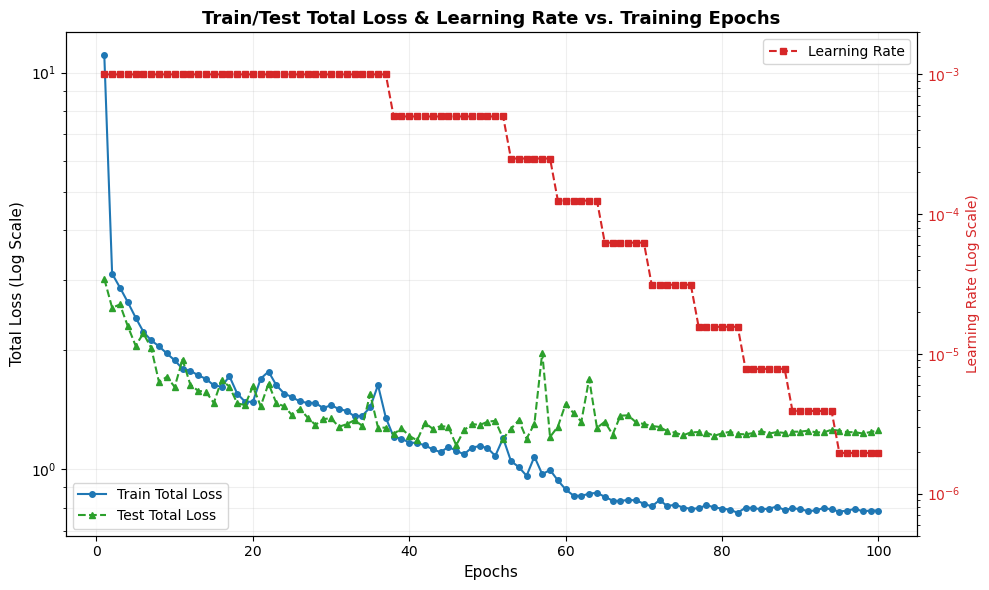

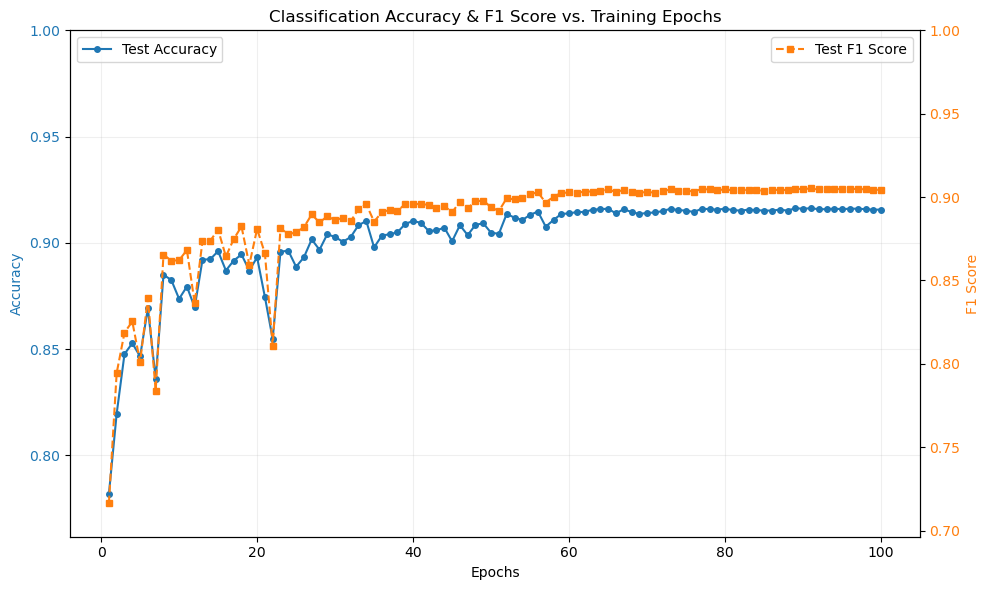

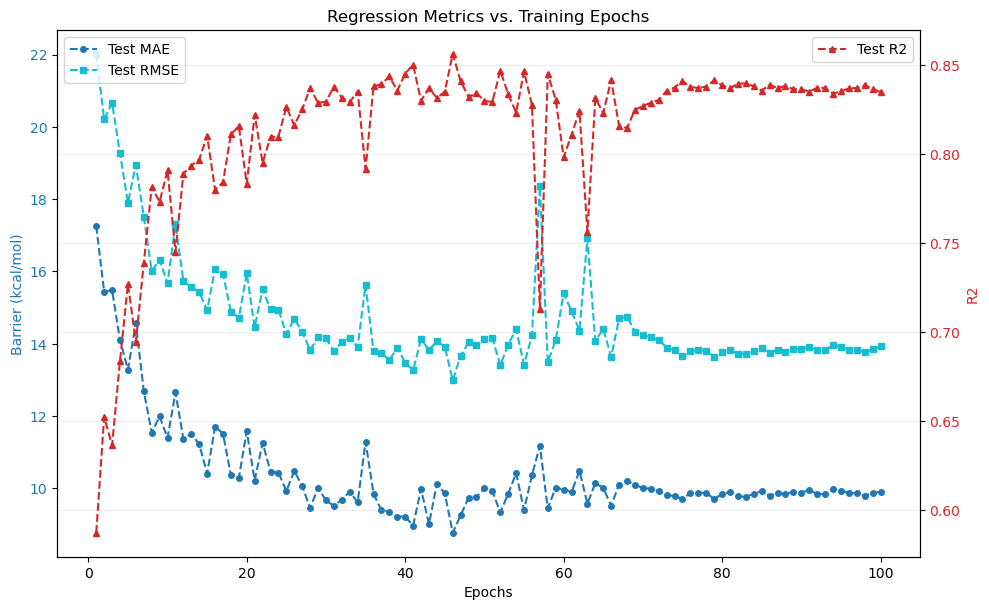

In [31]:
import json
import numpy as np
import matplotlib.pyplot as plt


# 日志文件路径（保持你的原始路径）
# log_file = './t1x_dim64_h8_n3_do0.2_w20_lrf0.8_lrp10_lr1e-3_ep200_bs128_ns0.2_lh4_fixed_lbd5e-3_focalloss2.0/1762264378.0235028/log.json'
log_file = './t1x_dim128_h8_n3_do0.2_w20_lrf0.5_lrp5_lr1e-3_ep100_bs128_ns0.2_lh4_fixed_lbd5e-3_focalloss2.0/1762322838.549689/log.json'

# 读取日志文件
with open(log_file, 'r') as f:
    log_data = json.load(f)

# 提取训练轮数
epochs = range(1, len(log_data['train_total_loss']) + 1)

# --------------------------
# 1. 总损失（左侧）+ 学习率（右侧）双y轴图
# --------------------------
# 训练集总损失
train_total_loss = log_data['train_total_loss']
# 学习率
train_lr = log_data['current_lr']
# 测试集总损失（从每轮test_metric中提取validation_loss→total_loss）
test_total_loss = []
for test_metric in log_data['test_metric']:
    # 从测试集指标中获取总损失（与eval_joint返回的validation_loss对应）
    test_total = test_metric['validation_loss']['total_loss']
    test_total_loss.append(test_total)

# 创建双y轴图
fig, ax1 = plt.subplots(figsize=(10, 6))

# 左侧y轴：训练集+测试集总损失（共用对数刻度）
color_train = 'tab:blue'
color_test = 'tab:green'
ax1.set_xlabel('Epochs', fontsize=11)
ax1.set_ylabel('Total Loss (Log Scale)', fontsize=11)
# 训练集loss：蓝色实线+圆形标记
ax1.plot(epochs, train_total_loss, label='Train Total Loss', 
         marker='o', markersize=4, color=color_train, linewidth=1.5)
# 测试集loss：绿色虚线+三角形标记（区分训练集）
ax1.plot(epochs, test_total_loss, label='Test Total Loss', 
         marker='^', markersize=4, color=color_test, linewidth=1.5, linestyle='--')
ax1.set_yscale('log')  # 保留对数刻度，便于观察损失变化
ax1.tick_params(axis='y', labelcolor='black')  # 损失轴标签用黑色（两个曲线共用）
ax1.legend(loc='lower left', fontsize=10)
ax1.grid(True, which="both", ls="-", alpha=0.2)

# 右侧y轴：学习率（对数刻度，适配指数衰减）
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Learning Rate (Log Scale)', color=color2)
ax2.plot(epochs, train_lr, label='Learning Rate', marker='s', markersize=4, color=color2, linestyle='--')
ax2.set_yscale('log')  # 学习率用对数刻度更清晰
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(5e-7, 2e-3)
ax2.legend(loc='upper right')

plt.title('Train/Test Total Loss & Learning Rate vs. Training Epochs', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

# --------------------------
# 2. 分类准确率（左侧）+ F1分数（右侧）双y轴图
# --------------------------
# 提取测试集的ACC和F1（从classification指标中获取）
test_acc = [item['classification']['ACC'] for item in log_data['test_metric']]
test_f1 = [item['classification']['F1'] for item in log_data['test_metric']]  # 新增F1提取

# 创建双y轴图
fig, ax1 = plt.subplots(figsize=(10, 6))

# 左侧y轴：分类准确率
color1 = 'tab:blue'
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy', color=color1)
ax1.plot(epochs, test_acc, label='Test Accuracy', marker='o', markersize=4, color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(max(0, min(test_acc) - 0.02), 1.0)  # 调整y轴范围，避免刻度太紧凑
ax1.legend(loc='upper left')
ax1.grid(True, ls="-", alpha=0.2)

# 右侧y轴：F1分数
ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.set_ylabel('F1 Score', color=color2)
ax2.plot(epochs, test_f1, label='Test F1 Score', marker='s', markersize=4, color=color2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(max(0, min(test_f1) - 0.02), 1.0)  # F1与ACC同范围（0-1）
ax2.legend(loc='upper right')

plt.title('Classification Accuracy & F1 Score vs. Training Epochs')
fig.tight_layout()
plt.show()

# --------------------------
# 3. 回归指标图（保持原始代码不变）
# --------------------------
# 提取测试集回归指标
test_mae = [item['regression']['MAE'] for item in log_data['test_metric']]
test_mse = [item['regression']['MSE'] for item in log_data['test_metric']]
test_rmse = [np.sqrt(mse) for mse in test_mse]  # 计算RMSE
test_r2 = [item['regression']['R2'] for item in log_data['test_metric']]

fig, ax1 = plt.subplots(figsize=(10, 6))

# 左侧y轴：MAE和RMSE
color = 'tab:blue'
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Barrier (kcal/mol)', color=color)
ax1.plot(epochs, test_mae, label='Test MAE', marker='o', markersize=4, linestyle='--', color='tab:blue')
ax1.plot(epochs, test_rmse, label='Test RMSE', marker='s', markersize=4, linestyle='--', color='tab:cyan')
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')

# 创建右侧y轴：R2
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('R2', color=color)  
ax2.plot(epochs, test_r2, label='Test R2', marker='^', markersize=4, linestyle='--', color='tab:red')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')

fig.tight_layout()  
plt.title('Regression Metrics vs. Training Epochs')
plt.grid(True, ls="-", alpha=0.2)
plt.show()

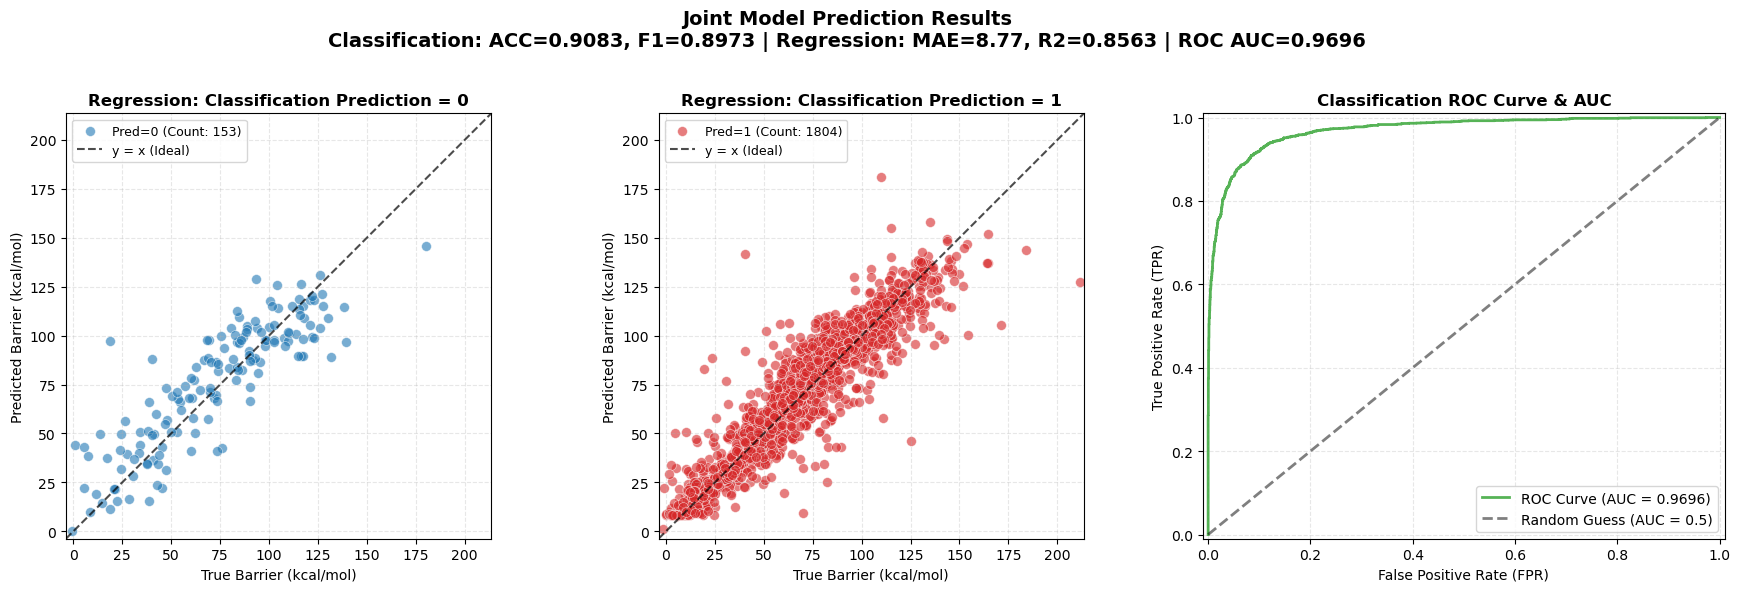

In [32]:
import json
import matplotlib.pyplot as plt
import numpy as np
import math
from sklearn.metrics import roc_curve, auc  # 用于计算AUC和ROC曲线

# --------------------------
# 配置参数（根据实际路径修改）
# --------------------------
# cls
json_file = './t1x_dim128_h8_n3_do0.2_w20_lrf0.5_lrp5_lr1e-3_ep100_bs128_ns0.2_lh4_fixed_lbd5e-3_focalloss2.0/1762322838.549689/t1x_test.json'

# --------------------------
# 1. 读取并解析JSON数据
# --------------------------
with open(json_file, 'r') as f:
    data = json.load(f)

# 提取核心数据（适配你的JSON字段名）
# 回归数据
reg_true_raw = data['regression']['true_values']
reg_pred_raw = data['regression']['pred_values']
# 分类数据（标签 + 指标）
cls_true_raw = data['classification']['true_labels']
cls_pred_raw = data['classification']['pred_labels']
cls_metrics = data['classification']['metrics']
# 回归指标
reg_metrics = data['regression']['metrics']

# --------------------------
# 2. 数据预处理（过滤NaN + 保持数据对齐）
# --------------------------
# 用于回归散点图的数据（需同时满足：回归值非NaN + 分类标签有效）
reg_true = []
reg_pred = []
cls_pred = []  # 分类预测结果（用于拆分散点图）

# 用于AUC图的数据（需满足：分类标签有效，且有预测得分）
# 注意：AUC需要「正类预测得分」（logits或概率），若你的JSON没有cls_scores，需先修改eval_joint返回
try:
    cls_scores_raw = data['classification']['cls_scores']  # 正类预测得分（假设已添加到JSON）
except KeyError:
    raise ValueError("计算AUC需要正类预测得分！请修改eval_joint函数，在返回结果中添加'cls_scores'（正类的logits或概率）")

cls_true_auc = []
cls_scores_auc = []

for t_reg, p_reg, t_cls, p_cls, score_cls in zip(
    reg_true_raw, reg_pred_raw, cls_true_raw, cls_pred_raw, cls_scores_raw
):
    # 过滤回归数据（非NaN）
    if isinstance(t_reg, (int, float)) and isinstance(p_reg, (int, float)):
        if not (math.isnan(t_reg) or math.isnan(p_reg)):
            reg_true.append(t_reg)
            reg_pred.append(p_reg)
            cls_pred.append(p_cls)
    
    # 过滤AUC数据（分类标签有效 + 得分有效）
    if isinstance(t_cls, (int, float)) and isinstance(score_cls, (int, float)):
        if t_cls in [0, 1]:  # 二分类标签校验
            cls_true_auc.append(t_cls)
            cls_scores_auc.append(score_cls)

# --------------------------
# 3. 计算关键参数（用于图表美化）
# --------------------------
# 回归数据范围（统一散点图坐标轴）
all_true_reg = reg_true
all_pred_reg = reg_pred
if all_true_reg and all_pred_reg:
    min_val = min(min(all_true_reg), min(all_pred_reg))
    max_val = max(max(all_true_reg), max(all_pred_reg))
    val_range = max_val - min_val
    min_plot = min_val - 0.01 * val_range  # 扩展1%避免点贴边
    max_plot = max_val + 0.01 * val_range
else:
    min_plot, max_plot = 0, 1  # 无数据时默认范围

# 分类关键指标（用于标题）
acc = cls_metrics['ACC']
f1 = cls_metrics['F1']
mae = reg_metrics['MAE']
r2 = reg_metrics['R2']

# --------------------------
# 4. 一行三列布局：散点图1 → 散点图2 → ROC图
# --------------------------
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))  # 横向宽画布

# --------------------------
# 子图1：分类预测=0的回归散点图（第一列）
# --------------------------
# 筛选分类预测=0的数据
reg_true_0 = [t for t, p in zip(reg_true, cls_pred) if p == 0]
reg_pred_0 = [pr for pr, p in zip(reg_pred, cls_pred) if p == 0]
# 绘制散点
ax1.scatter(reg_true_0, reg_pred_0, color='tab:blue', alpha=0.6,
            label=f'Pred=0 (Count: {len(reg_true_0)})', s=50, edgecolors='white', linewidth=0.5)
# 绘制y=x参考线（理想预测）
ax1.plot([min_plot, max_plot], [min_plot, max_plot], 'k--', alpha=0.7, label='y = x (Ideal)')
# 美化设置
ax1.set_xlabel('True Barrier (kcal/mol)', fontsize=10)
ax1.set_ylabel('Predicted Barrier (kcal/mol)', fontsize=10)
ax1.set_title('Regression: Classification Prediction = 0', fontsize=12, fontweight='bold')
ax1.set_xlim(min_plot, max_plot)
ax1.set_ylim(min_plot, max_plot)
ax1.set_aspect('equal', adjustable='box')  # 等比例坐标轴
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, linestyle='--')

# --------------------------
# 子图2：分类预测=1的回归散点图（第二列）
# --------------------------
# 筛选分类预测=1的数据
reg_true_1 = [t for t, p in zip(reg_true, cls_pred) if p == 1]
reg_pred_1 = [pr for pr, p in zip(reg_pred, cls_pred) if p == 1]
# 绘制散点
ax2.scatter(reg_true_1, reg_pred_1, color='tab:red', alpha=0.6,
            label=f'Pred=1 (Count: {len(reg_true_1)})', s=50, edgecolors='white', linewidth=0.5)
# 绘制y=x参考线
ax2.plot([min_plot, max_plot], [min_plot, max_plot], 'k--', alpha=0.7, label='y = x (Ideal)')
# 美化设置（与左图保持一致范围）
ax2.set_xlabel('True Barrier (kcal/mol)', fontsize=10)
ax2.set_ylabel('Predicted Barrier (kcal/mol)', fontsize=10)
ax2.set_title('Regression: Classification Prediction = 1', fontsize=12, fontweight='bold')
ax2.set_xlim(min_plot, max_plot)
ax2.set_ylim(min_plot, max_plot)
ax2.set_aspect('equal', adjustable='box')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, linestyle='--')

# --------------------------
# 子图3：ROC AUC图（第三列，最后一个）
# --------------------------
# 计算ROC曲线和AUC
fpr, tpr, _ = roc_curve(cls_true_auc, cls_scores_auc, pos_label=1)  # 正类标签=1
roc_auc = auc(fpr, tpr)
# 绘制ROC曲线
ax3.plot(fpr, tpr, color='tab:green', lw=2, alpha=0.8,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
# 绘制随机猜测线（AUC=0.5）
ax3.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5, label='Random Guess (AUC = 0.5)')
# 美化设置
ax3.set_xlabel('False Positive Rate (FPR)', fontsize=10)
ax3.set_ylabel('True Positive Rate (TPR)', fontsize=10)
ax3.set_title('Classification ROC Curve & AUC', fontsize=12, fontweight='bold')
ax3.set_xlim([-0.01, 1.01])
ax3.set_ylim([-0.01, 1.01])
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, linestyle='--')

# --------------------------
# 总标题（包含所有关键指标）
# --------------------------
fig.suptitle(
    f'Joint Model Prediction Results\n'
    f'Classification: ACC={acc:.4f}, F1={f1:.4f} | '
    f'Regression: MAE={mae:.2f}, R2={r2:.4f} | '
    f'ROC AUC={roc_auc:.4f}',
    fontsize=14, fontweight='bold', y=0.98
)

# 调整子图间距，避免重叠
plt.tight_layout(rect=[0, 0, 1, 0.96])  # 预留总标题空间
plt.show()

# 可选：保存高清图片
# fig.savefig('./prediction_results.png', dpi=300, bbox_inches='tight')
# print("图表绘制完成！")